# <p style="background-color:green;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b>Adult Income Prediction Project Solution</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>If you want to be the first to get informed of the most recent updates, then don't forget to follow us on:</b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [WhatsApp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [LinkedIn](https://www.linkedin.com/company/techproeducation/mycompany/) |

# <font color='green'> <b>Exploratory Data Analysis</b><font color='black'>

**Data Set Information:**

This dataset was obtained from UCI Machine Learning Repository. The aim of this problem is to classify adults in two different groups based on their income where group 1 has an income less than USD 50k and group 2 has an income of more than or equal to USD 50k. The data available at hand comes from Census 1994.

**Attribute Information:**

**Age**: Describes the age of individuals. Continuous.

**Workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.

**fnlwgt**: Continuous value. This is a weighting factor created by the U.S. Census Bureau, indicating the number of people that each data entry represents. For example, if the fnlwgt value for a data entry is 100, it means that this data entry is considered to represent 100 people.

However, this feature is not typically used directly in analyses or model training because these weights don't have a direct significance on individual data points when training or testing models. Nonetheless, these weight values can be useful if a more in-depth demographic analysis of the dataset is being conducted.

**education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.

**education-num**: Number of years spent in education. Continuous.

**marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.

**occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.

**relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.

**race**: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.

**sex**: Female, Male.

**capital-gain**: Represents the profit an individual makes from the sale of assets (e.g., stock or real estate sales). Continuous.

**capital-loss**: Represents the loss an individual incurs from the sale of assets (e.g., stock or real estate sales). Continuous.

**hours-per-week**: Continuous.

**native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

**salary**: >50K,<=50K.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, f1_score, recall_score, precision_score

plt.rcParams["figure.figsize"] = (10, 6)

import warnings

warnings.filterwarnings("ignore")
warnings.warn("this will not show")

In [2]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.shape

(32561, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [6]:
df.columns = df.columns.str.replace(".", "_")
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [7]:
df['occupation'] = df['occupation'].fillna(method='bfill')

In [8]:
def duplicate_values(df):
    print("Duplicate check...")
    num_duplicates = df.duplicated(subset=None, keep="first").sum()
    if num_duplicates > 0:
        print("There are", num_duplicates, "duplicated observations in the dataset.")
        df.drop_duplicates(keep="first", inplace=True)
        print(num_duplicates, "duplicates were dropped!")
        print("No more duplicate rows!")
    else:
        print("There are no duplicated observations in the dataset.")

duplicate_values(df)

Duplicate check...
There are 24 duplicated observations in the dataset.
24 duplicates were dropped!
No more duplicate rows!


In [9]:
df.workclass.unique()

array(['?', 'Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc',
       'Self-emp-inc', 'Local-gov', 'Without-pay', 'Never-worked'],
      dtype=object)

In [10]:
df['workclass'] = df['workclass'].replace('?', np.nan)

In [11]:
df.workclass.value_counts()

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [12]:
df.occupation.unique()

array(['?', 'Exec-managerial', 'Machine-op-inspct', 'Prof-specialty',
       'Other-service', 'Adm-clerical', 'Craft-repair',
       'Transport-moving', 'Handlers-cleaners', 'Sales',
       'Farming-fishing', 'Tech-support', 'Protective-serv',
       'Armed-Forces', 'Priv-house-serv'], dtype=object)

In [13]:
df['occupation'] = df['occupation'].replace('?', np.nan)

In [14]:
df.occupation.value_counts()

occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [15]:
df.occupation.isnull().sum()

np.int64(1843)

In [16]:
df.native_country.unique()

array(['United-States', '?', 'Mexico', 'Greece', 'Vietnam', 'China',
       'Taiwan', 'India', 'Philippines', 'Trinadad&Tobago', 'Canada',
       'South', 'Holand-Netherlands', 'Puerto-Rico', 'Poland', 'Iran',
       'England', 'Germany', 'Italy', 'Japan', 'Hong', 'Honduras', 'Cuba',
       'Ireland', 'Cambodia', 'Peru', 'Nicaragua', 'Dominican-Republic',
       'Haiti', 'El-Salvador', 'Hungary', 'Columbia', 'Guatemala',
       'Jamaica', 'Ecuador', 'France', 'Yugoslavia', 'Scotland',
       'Portugal', 'Laos', 'Thailand', 'Outlying-US(Guam-USVI-etc)'],
      dtype=object)

In [17]:
df['native_country'] = df['native_country'].replace('?', np.nan)

In [18]:
df.native_country.isnull().sum() 

np.int64(582)

In [19]:
df.relationship.unique()

array(['Not-in-family', 'Unmarried', 'Own-child', 'Other-relative',
       'Husband', 'Wife'], dtype=object)

In [20]:
df.race.unique()

array(['White', 'Black', 'Asian-Pac-Islander', 'Other',
       'Amer-Indian-Eskimo'], dtype=object)

In [21]:
df.sex.unique()

array(['Female', 'Male'], dtype=object)

In [22]:
df.income.unique()

array(['<=50K', '>50K'], dtype=object)

In [23]:
df.education.unique()

array(['HS-grad', 'Some-college', '7th-8th', '10th', 'Doctorate',
       'Prof-school', 'Bachelors', 'Masters', '11th', 'Assoc-acdm',
       'Assoc-voc', '1st-4th', '5th-6th', '12th', '9th', 'Preschool'],
      dtype=object)

In [24]:
df.marital_status.unique()

array(['Widowed', 'Divorced', 'Separated', 'Never-married',
       'Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

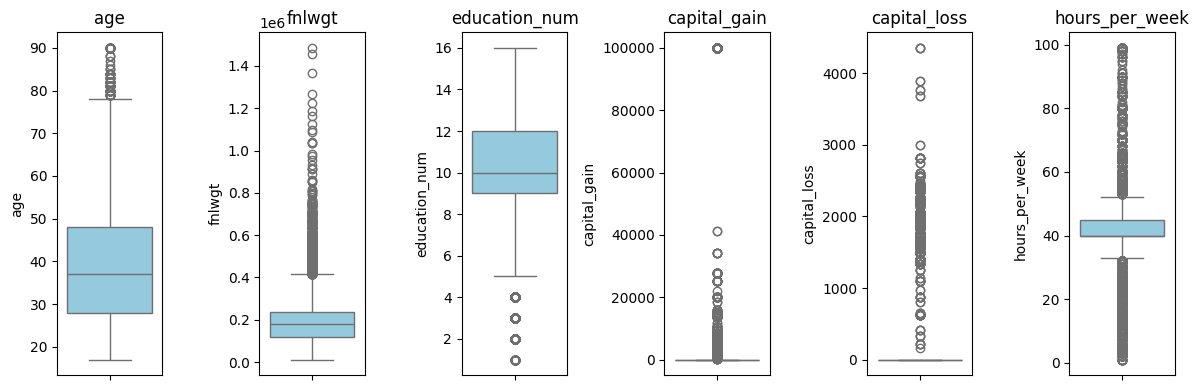

In [25]:
x = 0
numeric_columns = df.select_dtypes(include=['number']).columns
        
plt.figure(figsize=(16, 4))
for col in numeric_columns:
    x += 1
    plt.subplot(1, 8, x)
    sns.boxplot(data=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout() 
plt.show()

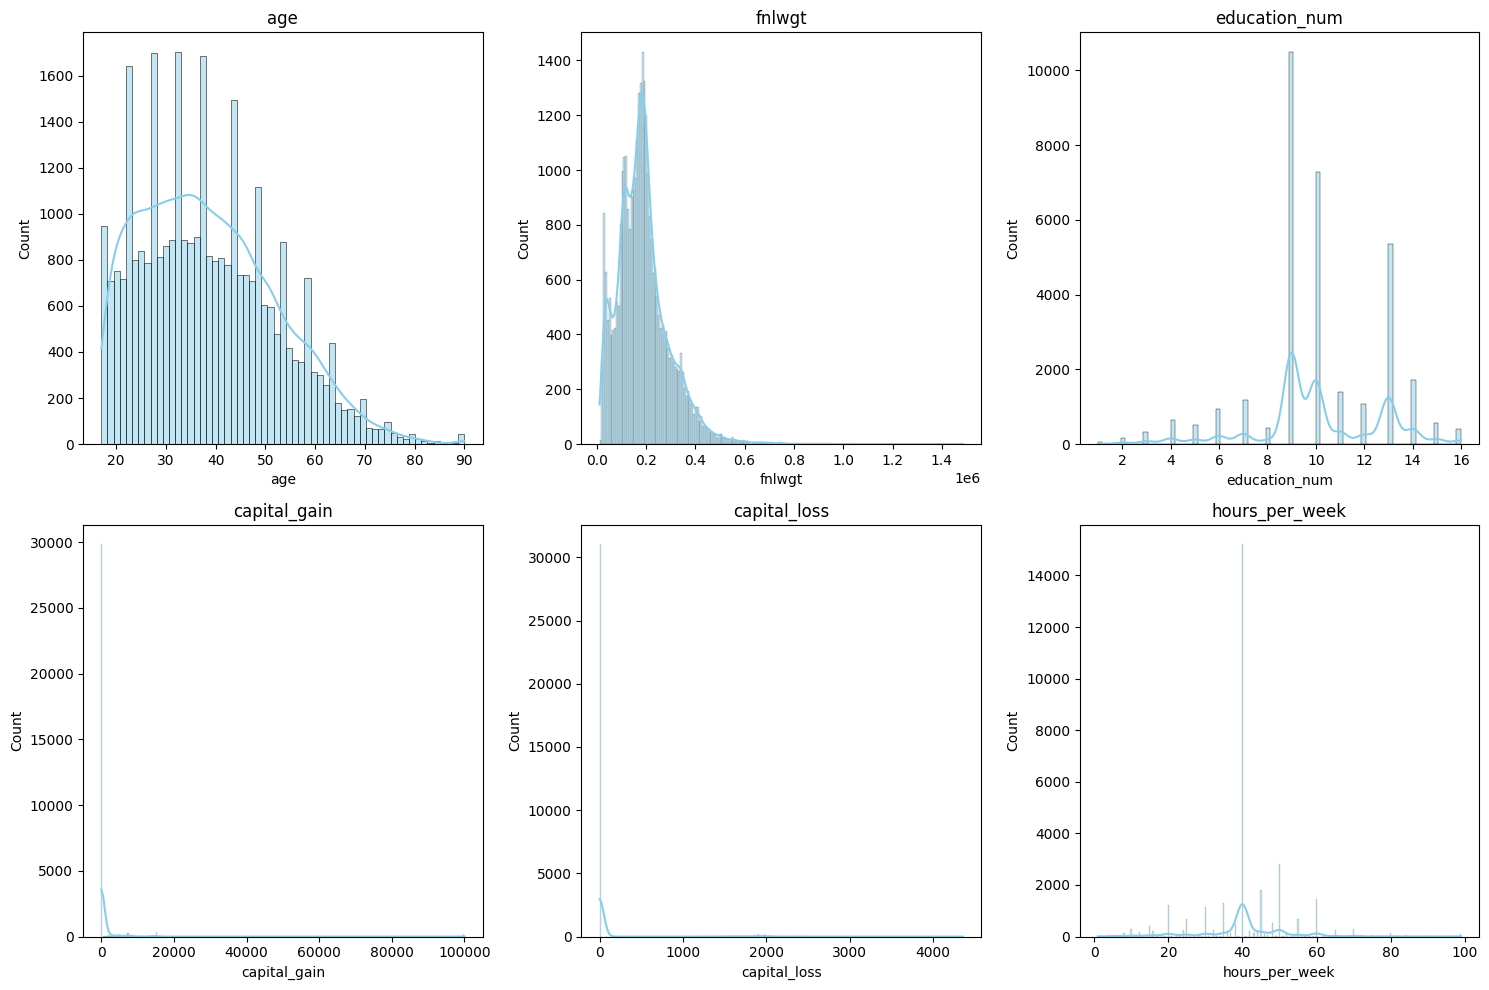

In [26]:
columns = numeric_columns
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, column in enumerate(columns):
    sns.histplot(df[column], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(column)
    
for i in range(len(columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

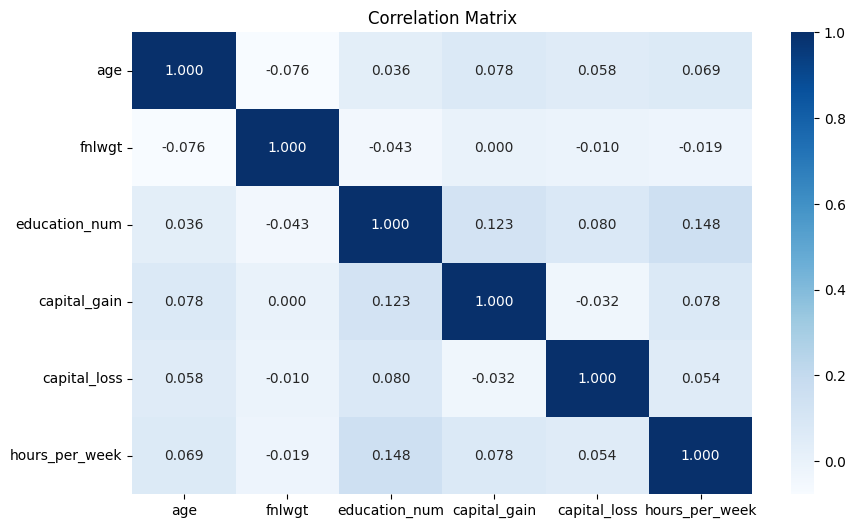

In [27]:
numeric_columns = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_columns.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".3f", cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

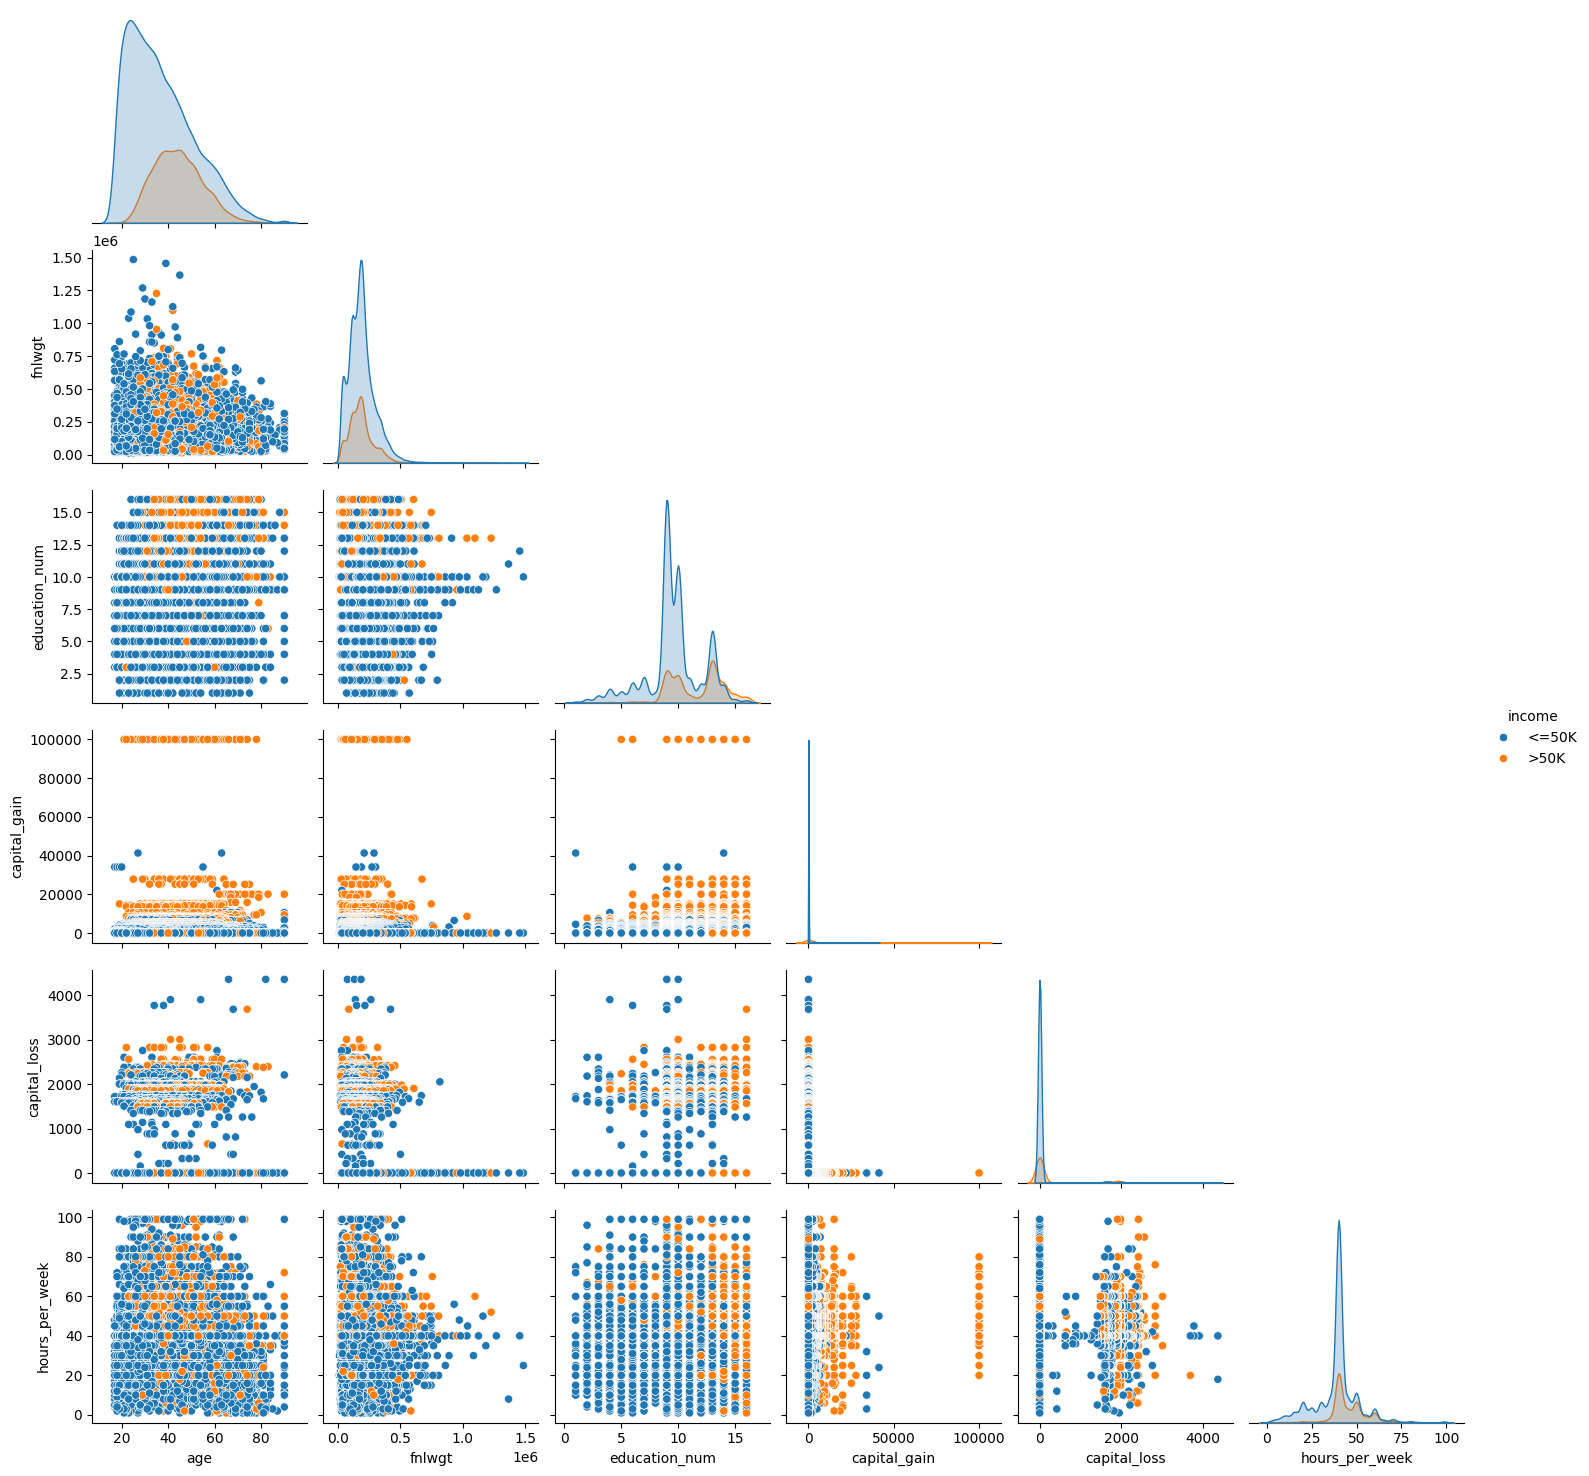

In [28]:
sns.pairplot(df, hue="income", corner=True);

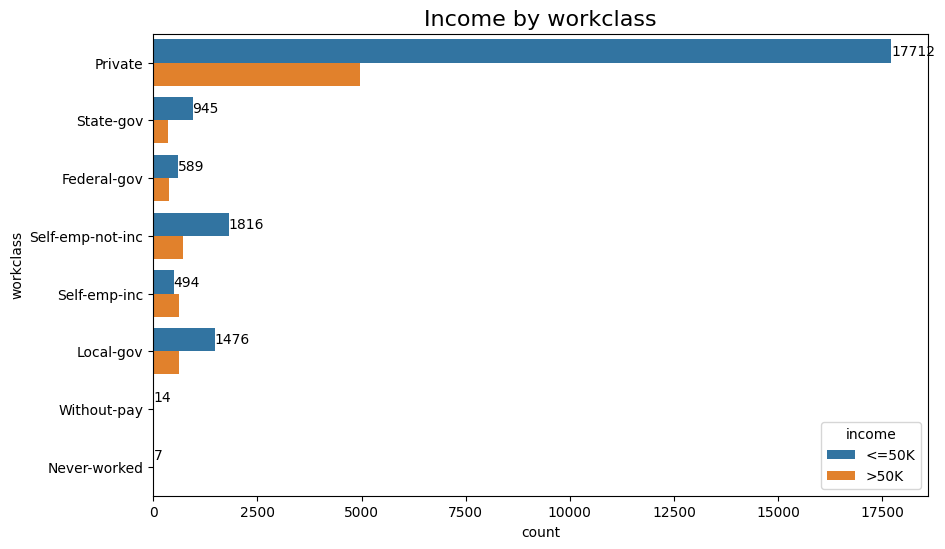

In [29]:
plt.figure(figsize = (10,6))
ax = sns.countplot(y = df['workclass'], hue = df['income'])
plt.title("Income by workclass", fontsize = 16)
ax.bar_label(ax.containers[0]);

In [30]:
df['workclass'] = df['workclass'].fillna('Private')

In [31]:
df.workclass.isnull().sum()

np.int64(0)

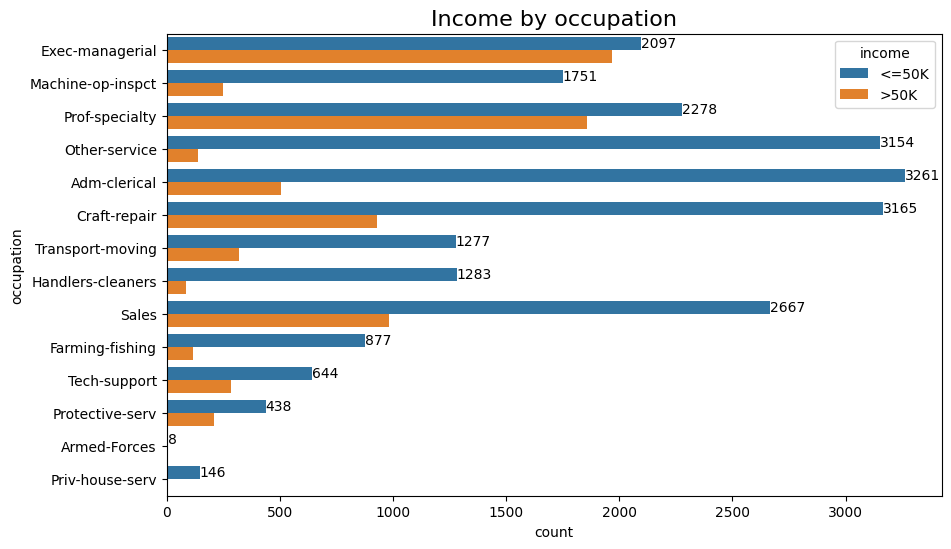

In [32]:
plt.figure(figsize = (10,6))
ax = sns.countplot(y = df['occupation'], hue = df['income'])
plt.title("Income by occupation", fontsize = 16)
ax.bar_label(ax.containers[0]);

In [33]:
df['occupation'] = df['occupation'].fillna(method='bfill')

In [34]:
df.occupation.isnull().sum()

np.int64(0)

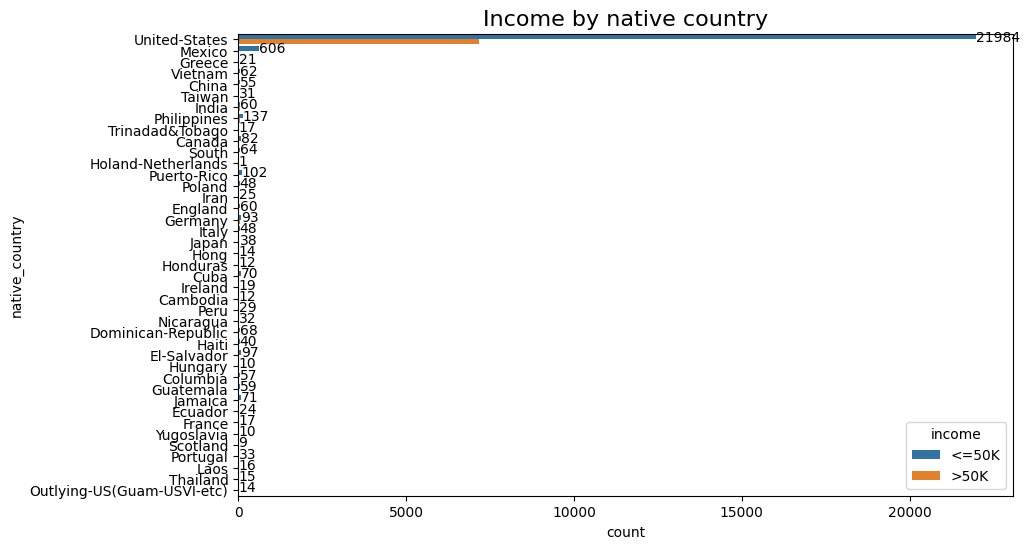

In [35]:
plt.figure(figsize = (10,6))
ax = sns.countplot(y = df['native_country'], hue = df['income'])
plt.title("Income by native country", fontsize = 16)
ax.bar_label(ax.containers[0]);

In [36]:
df['native_country'] = df['native_country'].fillna('United-States')

In [37]:
df.native_country.isnull().sum()

np.int64(0)

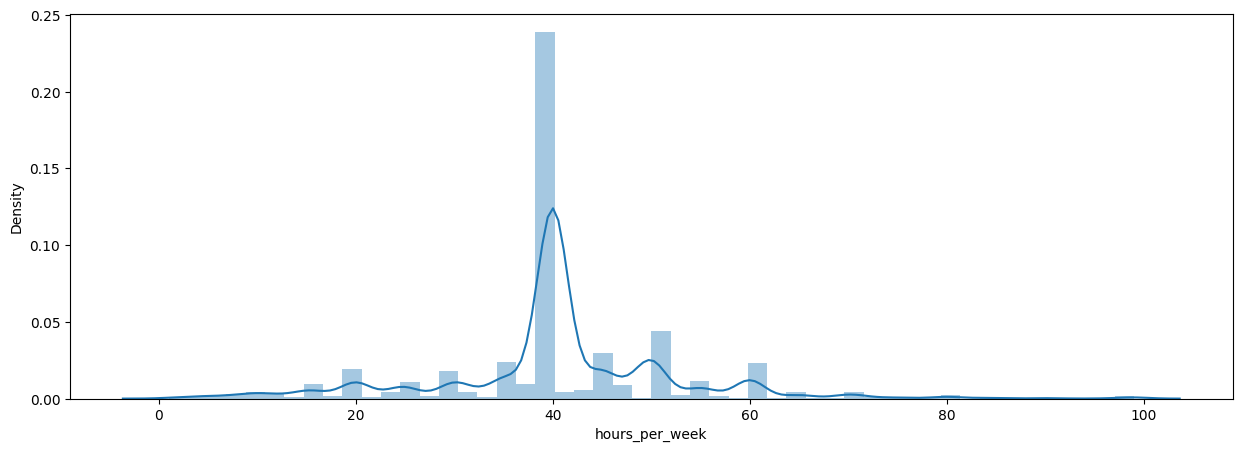

____________________________________________________________________________________________________
skewness in age column : 0.2287588778525044


In [38]:
plt.figure(figsize = (15,5))
sns.distplot(df["hours_per_week"], kde = True)

plt.show()
print("_"*100)
print("skewness in age column :",df["hours_per_week"].skew());

In [39]:
df = df[~((df["hours_per_week"] > 72) | (df["hours_per_week"] < 20))]

In [40]:
df['capital_diff'] = df['capital_gain'] - df['capital_loss']
df['capital_diff'] = pd.cut(df['capital_diff'], bins = [-5000, 5000, 100000], labels = ['Low', 'High'])
df['capital_diff'] = df['capital_diff'].astype('object')
df.drop(['capital_gain'], axis = 1, inplace = True)
df.drop(['capital_loss'], axis = 1, inplace = True)

In [41]:
df.drop(labels = ["fnlwgt"],axis = 1,inplace = True)

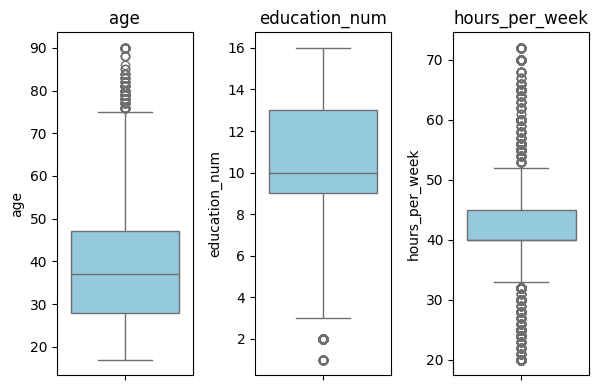

In [42]:
x = 0
numeric_columns = df.select_dtypes(include=['number']).columns
        
plt.figure(figsize=(16, 4))
for col in numeric_columns:
    x += 1
    plt.subplot(1, 8, x)
    sns.boxplot(data=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout() 
plt.show()

In [43]:
df = df[(df["workclass"] != "Without-pay") & (df["workclass"] != "Never-worked")]

In [44]:
df["education"].replace(["11th", "9th", "7th-8th", "5th-6th", "10th", "1st-4th", "12th"], "School", inplace = True)

In [45]:
df["race"].replace(["Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"],"Others", inplace = True)

In [46]:
df["native_country"].loc[df["native_country"] != "United-States"] = "Others"

In [47]:
df["marital_status"] = df["marital_status"].replace({
    "Married-civ-spouse": "Married",
    "Married-spouse-absent": "Married",
    "Married-AF-spouse": "Married",
    "Separated": "Married",
    "Never-married": "Single",
    "Divorced": "Single",
    "Widowed": "Single"
})

In [48]:
df['income']=df['income'].map({'<=50K': 0, '>50K': 1})

# <font color='green'> <b>Data Pre-Processing</b><font color='black'>

## Train | Test Split ##

In [49]:
df.income.value_counts()

income
0    22817
1     7577
Name: count, dtype: int64

In [50]:
X = df.drop(columns="income")
y = df.income

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

## Encoding ##

In [52]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [53]:
cat_onehot = ['workclass', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'marital_status']
cat_ordinal = ['education', 'capital_diff']
    
cat_for_edu = ['Preschool', 'School', 'HS-grad','Some-college', 'Assoc-voc', 'Assoc-acdm','Bachelors', 'Masters', 'Prof-school', 'Doctorate']
cat_for_capdiff = ['Low', 'High']

In [54]:
column_trans = make_column_transformer((OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_onehot), 
                                       (OrdinalEncoder(categories= [cat_for_edu, cat_for_capdiff]), cat_ordinal),
                                       remainder='passthrough')

In [55]:
X_train_trans = column_trans.fit_transform(X_train) 
X_test_trans = column_trans.transform(X_test)

In [56]:
column_trans.get_feature_names_out()

array(['onehotencoder__workclass_Federal-gov',
       'onehotencoder__workclass_Local-gov',
       'onehotencoder__workclass_Private',
       'onehotencoder__workclass_Self-emp-inc',
       'onehotencoder__workclass_Self-emp-not-inc',
       'onehotencoder__workclass_State-gov',
       'onehotencoder__occupation_Adm-clerical',
       'onehotencoder__occupation_Armed-Forces',
       'onehotencoder__occupation_Craft-repair',
       'onehotencoder__occupation_Exec-managerial',
       'onehotencoder__occupation_Farming-fishing',
       'onehotencoder__occupation_Handlers-cleaners',
       'onehotencoder__occupation_Machine-op-inspct',
       'onehotencoder__occupation_Other-service',
       'onehotencoder__occupation_Priv-house-serv',
       'onehotencoder__occupation_Prof-specialty',
       'onehotencoder__occupation_Protective-serv',
       'onehotencoder__occupation_Sales',
       'onehotencoder__occupation_Tech-support',
       'onehotencoder__occupation_Transport-moving',
       'oneh

In [57]:
features = column_trans.get_feature_names_out()

In [58]:
X_train= pd.DataFrame(X_train_trans, columns=features, index=X_train.index)
X_train.head()

,onehotencoder__workclass_Federal-gov,onehotencoder__workclass_Local-gov,onehotencoder__workclass_Private,onehotencoder__workclass_Self-emp-inc,onehotencoder__workclass_Self-emp-not-inc,onehotencoder__workclass_State-gov,onehotencoder__occupation_Adm-clerical,onehotencoder__occupation_Armed-Forces,onehotencoder__occupation_Craft-repair,onehotencoder__occupation_Exec-managerial,...,onehotencoder__sex_Male,onehotencoder__native_country_Others,onehotencoder__native_country_United-States,onehotencoder__marital_status_Married,onehotencoder__marital_status_Single,ordinalencoder__education,ordinalencoder__capital_diff,remainder__age,remainder__education_num,remainder__hours_per_week
5036,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,2.0,0.0,37.0,9.0,40.0
18433,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,17.0,5.0,26.0
3339,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,3.0,0.0,37.0,10.0,50.0
16648,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,28.0,7.0,40.0
15220,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,2.0,0.0,38.0,9.0,40.0


In [59]:
X_test= pd.DataFrame(X_test_trans, columns=features, index=X_test.index)
X_test.head()

,onehotencoder__workclass_Federal-gov,onehotencoder__workclass_Local-gov,onehotencoder__workclass_Private,onehotencoder__workclass_Self-emp-inc,onehotencoder__workclass_Self-emp-not-inc,onehotencoder__workclass_State-gov,onehotencoder__occupation_Adm-clerical,onehotencoder__occupation_Armed-Forces,onehotencoder__occupation_Craft-repair,onehotencoder__occupation_Exec-managerial,...,onehotencoder__sex_Male,onehotencoder__native_country_Others,onehotencoder__native_country_United-States,onehotencoder__marital_status_Married,onehotencoder__marital_status_Single,ordinalencoder__education,ordinalencoder__capital_diff,remainder__age,remainder__education_num,remainder__hours_per_week
29959,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,3.0,0.0,48.0,10.0,65.0
29815,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,0.0,2.0,0.0,29.0,9.0,40.0
12849,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,3.0,0.0,53.0,10.0,43.0
13503,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,4.0,0.0,32.0,11.0,40.0
27555,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,17.0,6.0,30.0


# <font color='green'> <b>Implement Logistic Regression</b><font color='black'>

## Cross Validation ##

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
operations = [("scaler", StandardScaler()), ("logistic", LogisticRegression())]

model = Pipeline(steps=operations)

scores = cross_validate(model, X_train, y_train,
                        scoring = ['accuracy', 'precision','recall','f1'],
                        cv = 10,
                        return_train_score=True)

df_scores = pd.DataFrame(scores, index = range(1, 11))
df_scores.mean()[2:]

test_accuracy      0.846802
train_accuracy     0.847488
test_precision     0.738694
train_precision    0.740146
test_recall        0.596765
train_recall       0.598178
test_f1            0.659944
train_f1           0.661631
dtype: float64

## GridSearchCV ##

In [62]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

In [63]:
operations = [("scaler", StandardScaler()), ("logistic", LogisticRegression())]

model = Pipeline(steps=operations)

penalty = ["l1", "l2"]
C = np.logspace(-1, 5, 20)
class_weight= ["balanced", None] 

solver = ["lbfgs", "liblinear", "sag", "saga"]

param_grid = {"logistic__penalty" : penalty,
              "logistic__C" : C,
              "logistic__class_weight":class_weight,
              "logistic__solver":solver}

cv = StratifiedKFold(n_splits = 5) 

log_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          cv=cv,
                          scoring = "recall",
                          n_jobs = -1,
                          return_train_score=True)

log_model.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'logistic__C': array([1.0000...00000000e+05]), 'logistic__class_weight': ['balanced', None], 'logistic__penalty': ['l1', 'l2'], 'logistic__solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [64]:
log_model.best_params_

{'logistic__C': np.float64(0.42813323987193935),
 'logistic__class_weight': 'balanced',
 'logistic__penalty': 'l1',
 'logistic__solver': 'liblinear'}

In [65]:
log_model.best_estimator_

,steps,"[('scaler', ...), ('logistic', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l1'
,dual,False
,tol,0.0001
,C,np.float64(0....3323987193935)


In [66]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

eval_metric(log_model, X_train, y_train, X_test, y_test)

Test_Set
[[3657  906]
 [ 260 1256]]
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      4563
           1       0.58      0.83      0.68      1516

    accuracy                           0.81      6079
   macro avg       0.76      0.81      0.77      6079
weighted avg       0.85      0.81      0.82      6079


Train_Set
[[14608  3646]
 [  964  5097]]
              precision    recall  f1-score   support

           0       0.94      0.80      0.86     18254
           1       0.58      0.84      0.69      6061

    accuracy                           0.81     24315
   macro avg       0.76      0.82      0.78     24315
weighted avg       0.85      0.81      0.82     24315



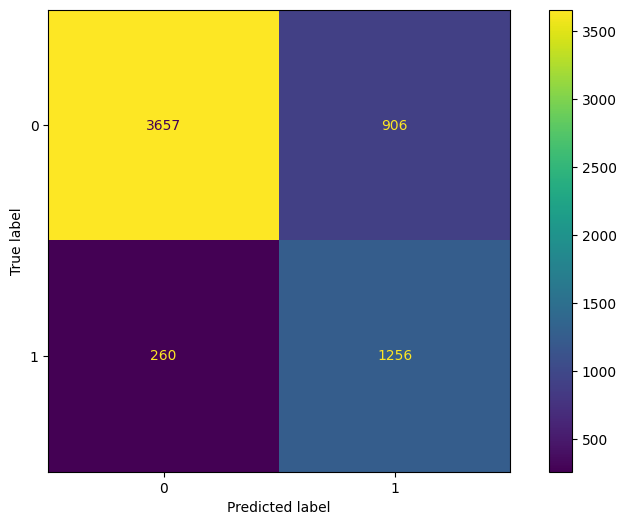

In [67]:
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test)
plt.show()

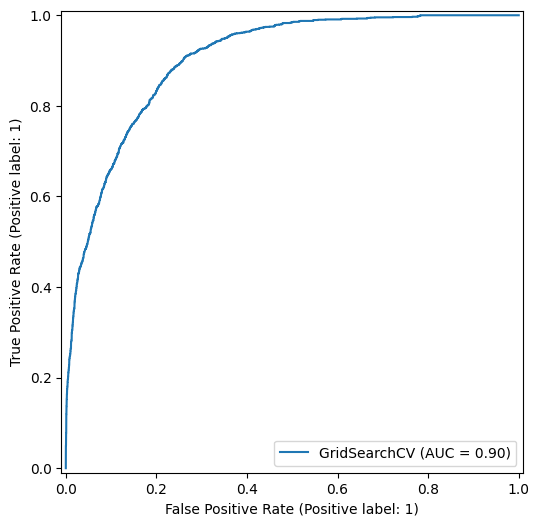

In [68]:
RocCurveDisplay.from_estimator(log_model, X_test, y_test);

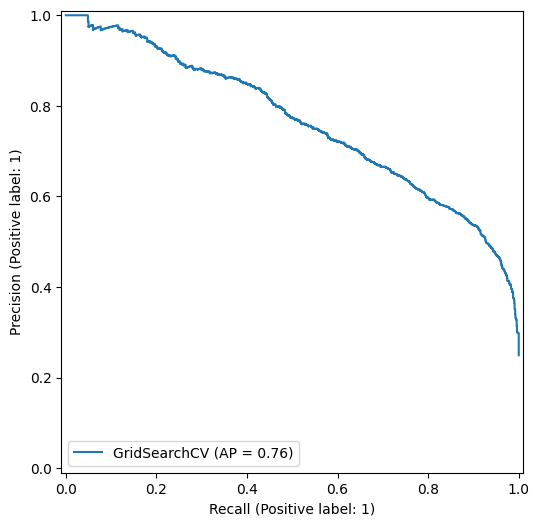

In [69]:
PrecisionRecallDisplay.from_estimator(log_model, X_test, y_test);

# <font color='green'> <b>K Nearest Neigbors (KNN)</b><font color='black'>

## Cross Validation ##

In [70]:
operations = [("scaler", StandardScaler()), ("knn", KNeighborsClassifier())]

model = Pipeline(steps=operations)

scores = cross_validate(model, X_train, y_train,
                        scoring = ['accuracy', 'precision','recall','f1'],
                        cv = 10,
                        return_train_score=True)

df_scores = pd.DataFrame(scores, index = range(1, 11))
df_scores.mean()[2:]

test_accuracy      0.828830
train_accuracy     0.877465
test_precision     0.673129
train_precision    0.781843
test_recall        0.609143
train_recall       0.705201
test_f1            0.639363
train_f1           0.741543
dtype: float64

## GridSearchCV ##

In [71]:
param_grid = [
    {
        "knn__n_neighbors": range(3, 10, 2),
        "knn__metric": ['euclidean', 'manhattan'],
        "knn__weights": ['uniform', 'distance']
    },
    {
        "knn__n_neighbors": range(3, 10, 2),
        "knn__metric": ['minkowski'],
        "knn__p": [1, 2],
        "knn__weights": ['uniform', 'distance']
    }
]

In [72]:
operations = [("scaler", StandardScaler()), ("knn", KNeighborsClassifier())]

model = Pipeline(steps=operations)

knn_model = GridSearchCV(model,
                              param_grid,
                              cv=5,
                              scoring= "accuracy",
                              return_train_score=True
                             )
knn_model.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"[{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': range(3, 10, 2), 'knn__weights': ['uniform', 'distance']}, {'knn__metric': ['minkowski'], 'knn__n_neighbors': range(3, 10, 2), 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [73]:
knn_model.best_params_

{'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}

In [74]:
knn_model.best_estimator_

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


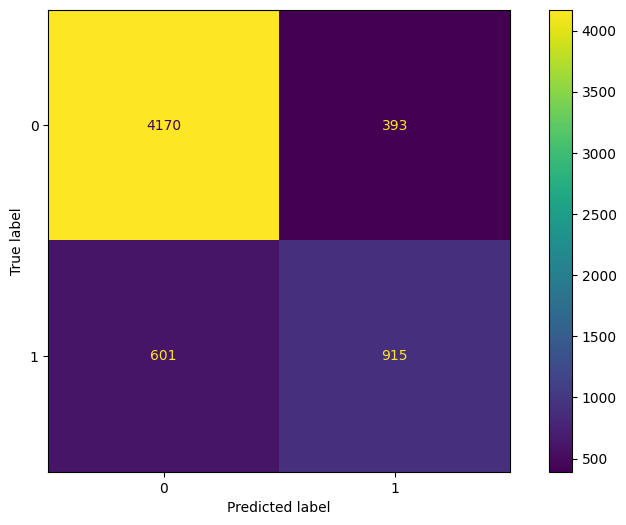

In [75]:
ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test)
plt.show()

In [76]:
eval_metric(knn_model, X_train, y_train, X_test, y_test)

Test_Set
[[4170  393]
 [ 601  915]]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4563
           1       0.70      0.60      0.65      1516

    accuracy                           0.84      6079
   macro avg       0.79      0.76      0.77      6079
weighted avg       0.83      0.84      0.83      6079


Train_Set
[[16990  1264]
 [ 2012  4049]]
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     18254
           1       0.76      0.67      0.71      6061

    accuracy                           0.87     24315
   macro avg       0.83      0.80      0.81     24315
weighted avg       0.86      0.87      0.86     24315



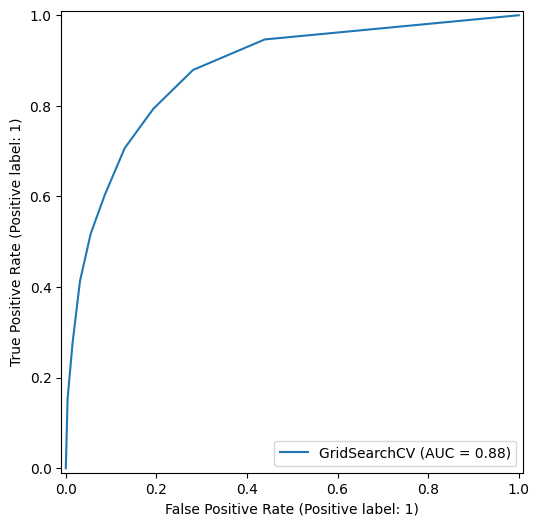

In [77]:
RocCurveDisplay.from_estimator(knn_model, X_test, y_test);

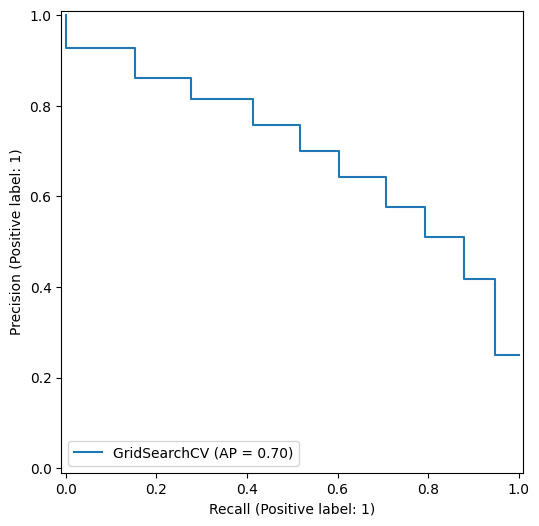

In [78]:
PrecisionRecallDisplay.from_estimator(knn_model, X_test, y_test);

# <font color='green'> <b>Implement Support Vector Machine (SVC)</b><font color='black'>

## Cross Validation ##

In [80]:
from sklearn.svm import SVC

In [81]:
operations = [("scaler", StandardScaler()), ("SVC", SVC())]

pipe_model = Pipeline(steps=operations)

scores = cross_validate(pipe_model,
                        X_train,
                        y_train,
                        scoring=['accuracy', 'precision', 'recall', 'f1'],
                        cv=10,
                        return_train_score=True)

df_scores = pd.DataFrame(scores, index=range(1, 11))
df_scores.mean()[2:]

test_accuracy      0.845568
train_accuracy     0.854137
test_precision     0.743052
train_precision    0.765351
test_recall        0.581753
train_recall       0.598269
test_f1            0.652276
train_f1           0.671567
dtype: float64

## GridSearchCV ##

In [82]:
param_grid = {'SVC__C': [0.01, 0.1, 0.5],
              'SVC__gamma': ["scale", "auto"],
              'SVC__kernel': ['rbf', 'linear']}

operations = [("scaler", StandardScaler()), ("SVC", SVC())]

model = Pipeline(steps=operations)

svm_model = GridSearchCV(model,
                              param_grid,
                              scoring="recall",
                              cv=5,
                              return_train_score=True,
                              n_jobs=1)
svm_model.fit(X_train, y_train)

,estimator,"Pipeline(step...SVC', SVC())])"
,param_grid,"{'SVC__C': [0.01, 0.1, ...], 'SVC__gamma': ['scale', 'auto'], 'SVC__kernel': ['rbf', 'linear']}"
,scoring,'recall'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [83]:
svm_model.best_params_

{'SVC__C': 0.5, 'SVC__gamma': 'scale', 'SVC__kernel': 'rbf'}

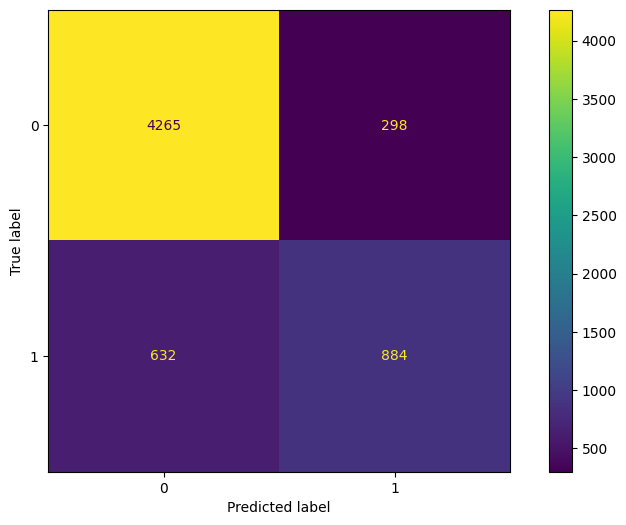

In [84]:
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test)
plt.show()

In [85]:
eval_metric(svm_model, X_train, y_train, X_test, y_test)

Test_Set
[[4265  298]
 [ 632  884]]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4563
           1       0.75      0.58      0.66      1516

    accuracy                           0.85      6079
   macro avg       0.81      0.76      0.78      6079
weighted avg       0.84      0.85      0.84      6079


Train_Set
[[17126  1128]
 [ 2490  3571]]
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     18254
           1       0.76      0.59      0.66      6061

    accuracy                           0.85     24315
   macro avg       0.82      0.76      0.78     24315
weighted avg       0.84      0.85      0.84     24315



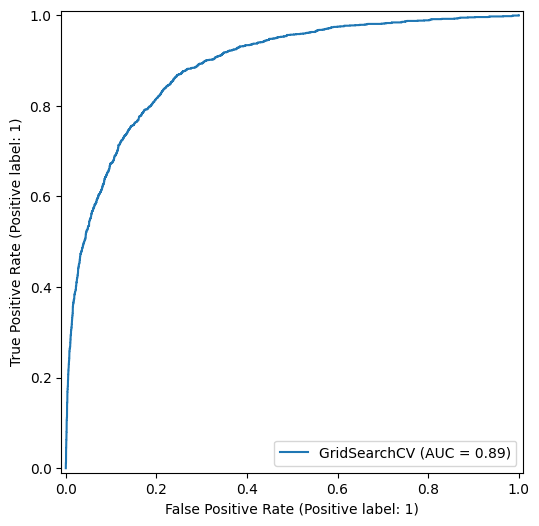

In [86]:
RocCurveDisplay.from_estimator(svm_model, X_test, y_test);

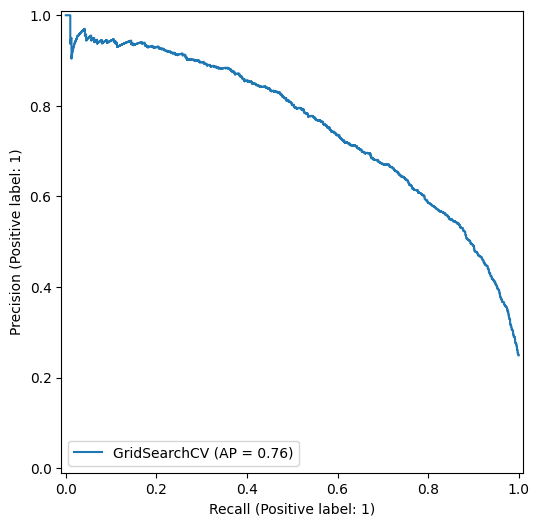

In [87]:
PrecisionRecallDisplay.from_estimator(svm_model, X_test, y_test);

# <font color='green'> <b>Conclusion</b><font color='black'>

## Final Model ##

In [88]:
cat_onehot = ['workclass', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'marital_status']
cat_ordinal = ['education', 'capital_diff']

cat_for_edu = ['Preschool', 'School', 'HS-grad','Some-college', 'Assoc-voc', 'Assoc-acdm','Bachelors', 'Masters', 'Prof-school', 'Doctorate']
cat_for_capdiff = ['Low', 'High']

In [89]:
column_trans = make_column_transformer((OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_onehot), 
                                       (OrdinalEncoder(categories= [cat_for_edu, cat_for_capdiff]), cat_ordinal),
                                       remainder='passthrough')

In [90]:
operations = [("encoding", column_trans), ("scaler", StandardScaler()), ("SVC", SVC(C=0.5, gamma='scale', kernel='rbf'))]

final_model = Pipeline(steps=operations)

final_model.fit(X,y)

,steps,"[('encoding', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('ordinalencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


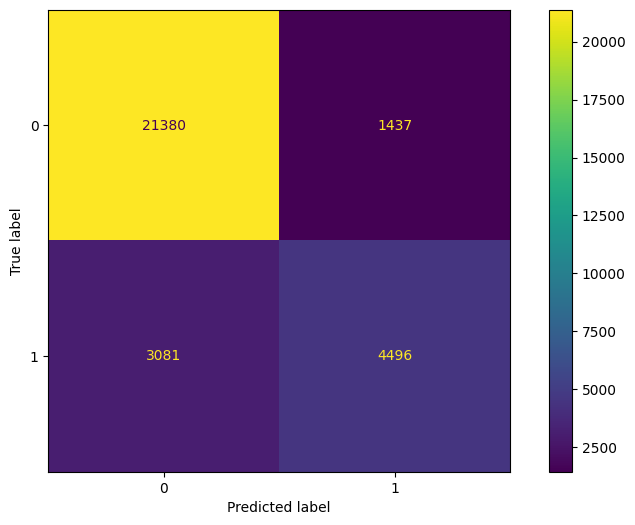

In [91]:
ConfusionMatrixDisplay.from_estimator(final_model, X, y)
plt.show()

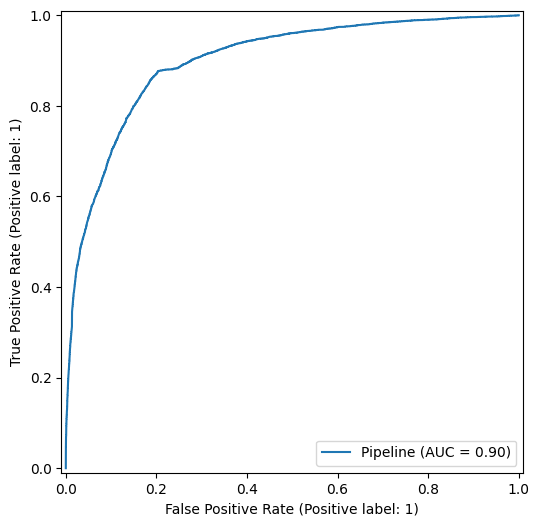

In [92]:
RocCurveDisplay.from_estimator(final_model, X, y);

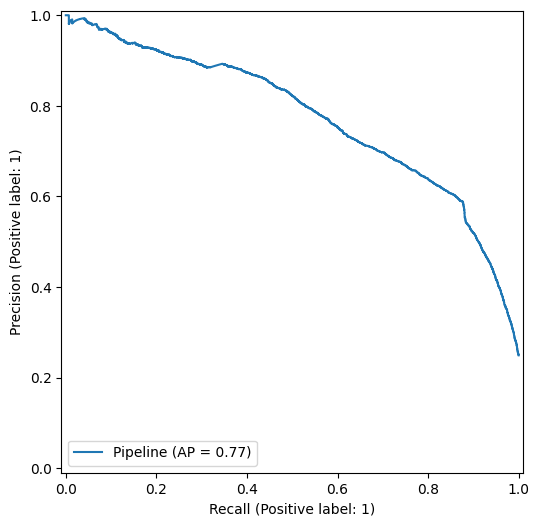

In [93]:
PrecisionRecallDisplay.from_estimator(final_model, X, y);

## Prediction ##

In [94]:
my_dict = {
    "age": [79, 25, 55, 58, 77, 79, 47, 36, 20, 50],
    "fnlwgt": [780331, 982486, 280349, 33829, 924365, 237596, 767527, 1005482, 1401535, 779651],
    "education_num": [12, 9, 16, 8, 4, 5, 15, 3, 8, 5],
    "capital_gain": [15402, 34156, 80276, 66660, 74477, 29406, 8484, 70080, 54144, 41333],
    "capital_loss": [3963, 1707, 867, 1360, 1795, 4071, 3951, 645, 2609, 2837],
    "hours_per_week": [53, 74, 82, 74, 26, 5, 24, 9, 23, 8],
    "workclass": [
        "Self-emp-inc", "Federal-gov", "State-gov", "Private", "Self-emp-not-inc",
        "State-gov", "Self-emp-inc", "State-gov", "Self-emp-inc", "State-gov"
    ],
    "education": [
        "HS-grad", "Masters", "HS-grad", "11th", "10th",
        "10th", "Prof-school", "Bachelors", "HS-grad", "10th"
    ],
    "marital_status": [
        "Separated", "Married-civ-spouse", "Married-AF-spouse", "Married-civ-spouse",
        "Separated", "Married-civ-spouse", "Divorced", "Married-spouse-absent",
        "Separated", "Widowed"
    ],
    "occupation": [
        "Farming-fishing", "Machine-op-inspct", "Exec-managerial", "Protective-serv",
        "Exec-managerial", "Farming-fishing", "Machine-op-inspct",
        "Adm-clerical", "Adm-clerical", "Sales"
    ],
    "relationship": [
        "Husband", "Wife", "Not-in-family", "Other-relative", "Wife",
        "Not-in-family", "Husband", "Wife", "Other-relative", "Unmarried"
    ],
    "race": [
        "Asian-Pac-Islander", "Amer-Indian-Eskimo", "White", "Black",
        "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Asian-Pac-Islander",
        "Black", "Black", "Amer-Indian-Eskimo"
    ],
    "sex": ["Female", "Male", "Male", "Male", "Male", "Female", "Male", "Male", "Male", "Male"],
    "native_country": [
        "Cuba", "Jamaica", "Puerto-Rico", "Ireland", "El-Salvador",
        "Laos", "Outlying-US(Guam-USVI-etc)", "Laos", "Cuba", "Puerto-Rico"
    ]
}

sample = pd.DataFrame(my_dict)
sample

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass,education,marital_status,occupation,relationship,race,sex,native_country
0,79,780331,12,15402,3963,53,Self-emp-inc,HS-grad,Separated,Farming-fishing,Husband,Asian-Pac-Islander,Female,Cuba
1,25,982486,9,34156,1707,74,Federal-gov,Masters,Married-civ-spouse,Machine-op-inspct,Wife,Amer-Indian-Eskimo,Male,Jamaica
2,55,280349,16,80276,867,82,State-gov,HS-grad,Married-AF-spouse,Exec-managerial,Not-in-family,White,Male,Puerto-Rico
3,58,33829,8,66660,1360,74,Private,11th,Married-civ-spouse,Protective-serv,Other-relative,Black,Male,Ireland
4,77,924365,4,74477,1795,26,Self-emp-not-inc,10th,Separated,Exec-managerial,Wife,Asian-Pac-Islander,Male,El-Salvador
5,79,237596,5,29406,4071,5,State-gov,10th,Married-civ-spouse,Farming-fishing,Not-in-family,Amer-Indian-Eskimo,Female,Laos
6,47,767527,15,8484,3951,24,Self-emp-inc,Prof-school,Divorced,Machine-op-inspct,Husband,Asian-Pac-Islander,Male,Outlying-US(Guam-USVI-etc)
7,36,1005482,3,70080,645,9,State-gov,Bachelors,Married-spouse-absent,Adm-clerical,Wife,Black,Male,Laos
8,20,1401535,8,54144,2609,23,Self-emp-inc,HS-grad,Separated,Adm-clerical,Other-relative,Black,Male,Cuba
9,50,779651,5,41333,2837,8,State-gov,10th,Widowed,Sales,Unmarried,Amer-Indian-Eskimo,Male,Puerto-Rico


In [95]:
sample.drop(labels = ["fnlwgt"],axis = 1,inplace = True)

In [96]:
sample['capital_diff'] = sample['capital_gain'] - sample['capital_loss']
sample['capital_diff'] = pd.cut(sample['capital_diff'], bins = [-5000, 5000, 100000], labels = ['Low', 'High'])
sample['capital_diff'] = sample['capital_diff'].astype('object')
sample.drop(['capital_gain'], axis = 1, inplace = True)
sample.drop(['capital_loss'], axis = 1, inplace = True)

In [97]:
sample = sample[(sample["workclass"] != "Without-pay") & (sample["workclass"] != "Never-worked")]

In [98]:
sample["education"].replace(["11th", "9th", "7th-8th", "5th-6th", "10th", "1st-4th", "12th"], "School", inplace = True)

In [99]:
sample["race"].replace(["Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"],"Others", inplace = True)

In [100]:
sample["native_country"].loc[sample["native_country"] != "United-States"] = "Others"

In [101]:
sample["marital_status"] = sample["marital_status"].replace({
    "Married-civ-spouse": "Married",
    "Married-spouse-absent": "Married",
    "Married-AF-spouse": "Married",
    "Separated": "Married",
    "Never-married": "Single",
    "Divorced": "Single",
    "Widowed": "Single"
})
sample

,age,education_num,hours_per_week,workclass,education,marital_status,occupation,relationship,race,sex,native_country,capital_diff
0,79,12,53,Self-emp-inc,HS-grad,Married,Farming-fishing,Husband,Others,Female,Others,High
1,25,9,74,Federal-gov,Masters,Married,Machine-op-inspct,Wife,Others,Male,Others,High
2,55,16,82,State-gov,HS-grad,Married,Exec-managerial,Not-in-family,White,Male,Others,High
3,58,8,74,Private,School,Married,Protective-serv,Other-relative,Black,Male,Others,High
4,77,4,26,Self-emp-not-inc,School,Married,Exec-managerial,Wife,Others,Male,Others,High
5,79,5,5,State-gov,School,Married,Farming-fishing,Not-in-family,Others,Female,Others,High
6,47,15,24,Self-emp-inc,Prof-school,Single,Machine-op-inspct,Husband,Others,Male,Others,Low
7,36,3,9,State-gov,Bachelors,Married,Adm-clerical,Wife,Black,Male,Others,High
8,20,8,23,Self-emp-inc,HS-grad,Married,Adm-clerical,Other-relative,Black,Male,Others,High
9,50,5,8,State-gov,School,Single,Sales,Unmarried,Others,Male,Others,High


In [102]:
prediction = final_model.predict(sample)
prediction

array([1, 1, 1, 0, 1, 0, 0, 0, 0, 0])

In [103]:
prediction_proba = final_model.decision_function(sample)
prediction_proba

array([ 0.01884872,  0.07756782,  0.44329323, -0.21657941,  0.0738591 ,
       -0.46078782, -0.59190831, -0.3832716 , -0.38231393, -0.38265514])

## Why we choose this model? ##

**Logistic Model**

Recall for class 1: 0.63

Precision: 0.56

Accuracy: 0.76. 

Logistic Regression showed relatively good performance on imbalanced data, but recall and precision values for class 1 remained low.

**KNN Model**

Recall for class 1: 0.61 

Precision: 0.56 

Accuracy: 0.79. 

The KNN model performed similarly to Logistic Regression, with a slightly higher accuracy score.

**SVM Model**

Recall for class 1: 0.68 (highest)

Precision: 0.58 (highest)

Accuracy: 0.80. 

The SVM model demonstrated the best performance in identifying class 1 on imbalanced data compared to other models.

In conclusion, it has been decided that the SVM model should be selected as the final model. This model achieved the highest recall and precision values for class 1, ensuring better identification of the minority class in the imbalanced dataset.

# <p style="background-color:green;font-family:newtimeroman;font-size:150%;color:white;text-align:center;border-radius:20px 20px;"><b>Thanks and Hoping it will be usefull</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>If you want to be the first to get informed of the most recent updates, then don't forget to follow us on</b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [WhatsApp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [LinkedIn](https://www.linkedin.com/company/techproeducation/mycompany/) |